<!-- # Visualisations

Loads saved results from `Results/` and produces publication-quality figures.
Each figure is saved to `Plots/` as a PDF (+ PNG) with metadata embedded in
a sidecar `_meta.json` file.

**Run order**
1. *Setup* — imports, style, helpers
2. *Q(k) diagnostics* — raw and interpolated self-energy
3. *Exciton & photon dispersion*
4. *Lower polariton dispersion*
5. *Hopfield coefficients*
6. *Detuning*
7. *Interaction strengths vs k* -->


In [1]:
import sys
sys.path.insert(0, '.')

import json
import datetime
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.interpolate import PchipInterpolator

from polaritons.io         import load_result, load_latest
from polaritons.dispersion import DispersionModel
from polaritons.many_body  import (
	hopfield_coefficients,
	polariton_interaction_strength,
	Pi0,
)
from polaritons.parameters import Params

# ---------------------------------------------------------------------------
# Matplotlib style
# ---------------------------------------------------------------------------
CMAP_NAME = "magma"
CMAP = plt.get_cmap(CMAP_NAME)

plt.rcParams.update({
	'font.family'               : 'serif',
	'font.serif'                : ['DejaVu Serif'],
	'font.size'                 : 14,
	'axes.labelsize'            : 16,
	'axes.titlesize'            : 16,
	'xtick.labelsize'           : 14,
	'ytick.labelsize'           : 14,
	'legend.fontsize'           : 13,
	'figure.titlesize'          : 18,
	'axes.formatter.limits'     : (-99, 99),
	'image.cmap'                : CMAP_NAME,
})

PLOTS_DIR = Path("Plots")
PLOTS_DIR.mkdir(exist_ok=True)
K_SI_TO_CM = 0.01

# ---------------------------------------------------------------------------
# Shared plotting helpers
# ---------------------------------------------------------------------------

def k_si_to_cm(k_si):
	return K_SI_TO_CM * np.asarray(k_si, dtype=float)


def q_nat_to_cm(q_nat, p_si: Params):
	return K_SI_TO_CM * np.asarray(q_nat, dtype=float) / p_si.a


def eta_color(index: int, total: int):
	denom = max(total - 1, 1)
	return CMAP(0.12 + 0.83 * index / denom)


def cavity_label(disorder_tuned: bool) -> str:
	return "disorder-tuned cavity" if disorder_tuned else "disorder-free cavity"


def cavity_slug(disorder_tuned: bool) -> str:
	return "disorder_tuned" if disorder_tuned else "disorder_free"


def format_cm_ticks(ax, xmax: float):
	if xmax <= 100_000:
		ticks = np.linspace(0, xmax, 5)
		ax.set_xticks(ticks)
		ax.set_xticklabels([f"{int(x):,}" for x in ticks])

# ---------------------------------------------------------------------------
# Figure-saving helper
# ---------------------------------------------------------------------------

def save_figure(fig: plt.Figure, name: str, meta: dict | None = None,
				dpi: int = 150) -> None:
	"""
	Save `fig` to Plots/<name>.pdf and Plots/<name>.png, and write metadata
	to Plots/<name>_meta.json.
	"""
	pdf_path  = PLOTS_DIR / f"{name}.pdf"
	png_path  = PLOTS_DIR / f"{name}.png"
	json_path = PLOTS_DIR / f"{name}_meta.json"

	fig.savefig(pdf_path, bbox_inches="tight")
	fig.savefig(png_path, bbox_inches="tight", dpi=dpi)

	record = {
		"saved_at" : datetime.datetime.now(datetime.timezone.utc).isoformat(),
		"pdf"      : str(pdf_path),
		"png"      : str(png_path),
		"cmap"     : CMAP_NAME,
		**(meta or {}),
	}
	with open(json_path, "w") as f:
		json.dump(record, f, indent=2, default=str)
	print(f"Saved  {pdf_path.name}")

print("Setup complete.")


Setup complete.


## Load results

Choose which saved result set to visualise.  By default the most recently
saved Q result is loaded; change `Q_STEM` / `SWEEP_IDX` to pick a specific run.


In [2]:
# Set Q_STEM = None to auto-load the most recent result
Q_STEM = None

if Q_STEM is None:
	Q_results, q_meta = load_latest("Results/Q_results", prefix="Q")
else:
	Q_results, q_meta = load_result("Results/Q_results", Q_STEM)

print(f"Loaded Q_results  shape={Q_results.shape}  dtype={Q_results.dtype}")
print(f"  saved_at : {q_meta['saved_at']}")
print(f"  xi       : {q_meta['params']['xi']:.2e} m")

# Reconstruct SI Params from metadata
raw = q_meta["params"]
p_si = Params(
	E_bind       = raw["E_bind"],
	E_gap_bare   = raw["E_gap_bare"],
	m_e          = raw["m_e"],
	m_h          = raw["m_h"],
	m_rest       = raw["m_rest"],
	Omega        = raw["Omega"],
	m_prime      = raw["m_prime"],
	n_refr       = raw.get("n_refr", 3.0),
	N_qw         = raw.get("N_qw", 1),
	D_0          = raw["D_0"],
	xi           = raw["xi"],
	T            = raw["T"],
	concentration = raw["concentration"],
	g_ex         = raw["g_ex"],
)

eta_grid = np.array(q_meta["eta_grid"])
q_picard = np.array(q_meta["q_picard"])   # natural units

# Build dispersion model.  Public model inputs are SI; Q grid/results are natural.
model = DispersionModel(p_si, q_picard, eta_grid, Q_results)

# Momentum grids for plotting (SI, m^-1)
k_disp = np.linspace(0.0, 4e6, 200)    # standard range, 0..40,000 cm^-1
k_domain_max = float(q_picard.max() / p_si.a)
first_positive_k = float(q_picard[q_picard > 0][0] / p_si.a)
k_wide = np.linspace(0.0, k_domain_max, 500)
k_full_log = np.geomspace(first_positive_k, k_domain_max, 700)

print(f"\nParams: E_bind={p_si.E_bind*1e3:.1f} meV  Omega={p_si.Omega*1e3:.1f} meV  "
	  f"T={p_si.T:.0f} K  xi={p_si.xi*1e9:.0f} nm")
print(f"Momentum domain: 0 to {k_si_to_cm(k_domain_max):.3g} cm^-1")


Loaded Q_results  shape=(21, 10000)  dtype=complex128
  saved_at : 2026-05-01T17:14:16.156264+00:00
  xi       : 4.00e-08 (natural units)

Params: E_bind=4.2 meV  Omega=14.0 meV  T=20 K  xi=40 nm


## Q(k) diagnostics

Raw and interpolated self-energy for selected disorder values.


Saved  Q_diagnostics.pdf


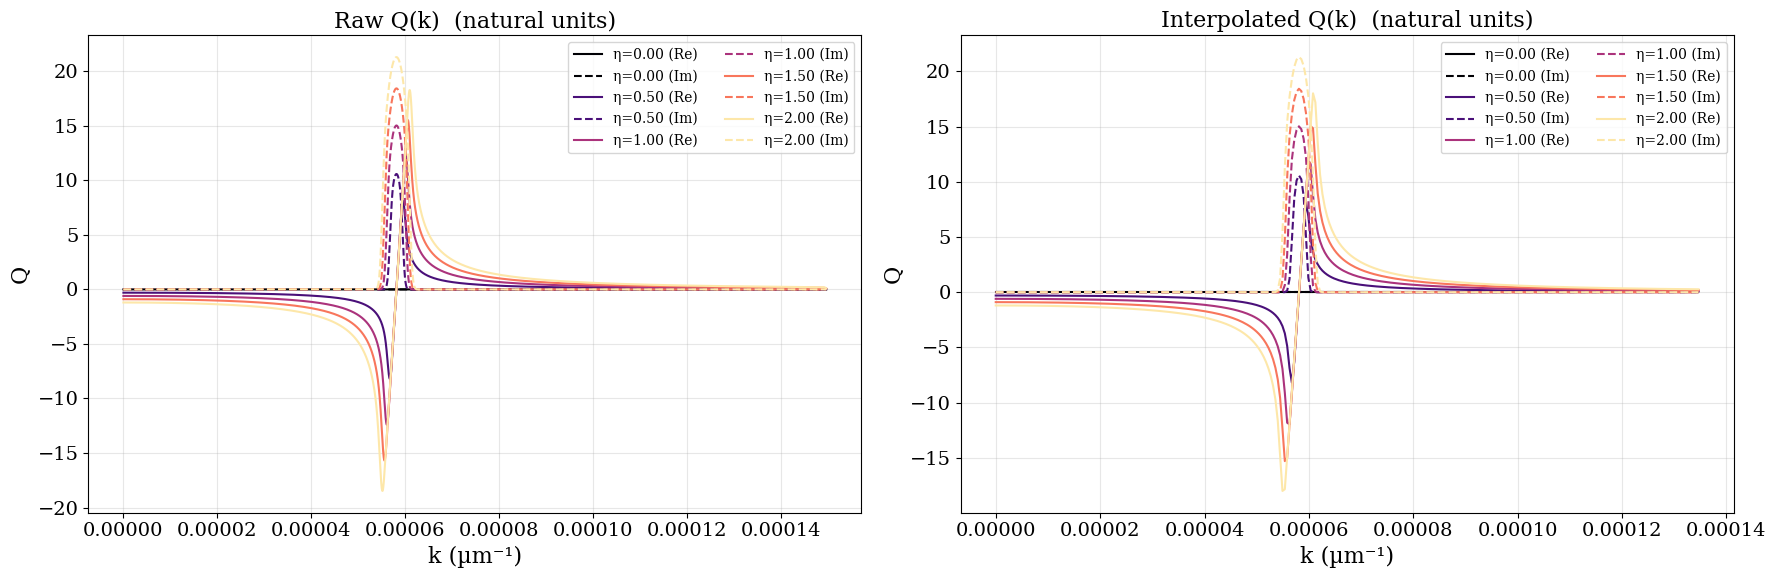

In [3]:
plot_eta_idx = [0, 5, 10, 15, 20]

fig, axs = plt.subplots(1, 2, figsize=(18, 6))

for idx in plot_eta_idx:
	clr = eta_color(idx, len(eta_grid))
	lbl = f"η={eta_grid[idx]:.2f}"
	axs[0].plot(q_nat_to_cm(q_picard, p_si), Q_results[idx].real,
				color=clr, label=f"{lbl} (Re)")
	axs[0].plot(q_nat_to_cm(q_picard, p_si), Q_results[idx].imag,
				color=clr, linestyle='--', label=f"{lbl} (Im)")

	k_si_test = np.linspace(0, 0.9 * k_domain_max, 300)
	Q_interp  = model.Q(k_si_test, eta_grid[idx])
	axs[1].plot(k_si_to_cm(k_si_test), np.real(Q_interp) / p_si.E_bind,
				color=clr, label=f"{lbl} (Re)")
	axs[1].plot(k_si_to_cm(k_si_test), np.imag(Q_interp) / p_si.E_bind,
				color=clr, linestyle='--', label=f"{lbl} (Im)")

for ax, title in zip(axs, ["Raw Q(k)  (natural units)", "Interpolated Q(k)  (natural units)"]):
	ax.set_xlabel("k (cm⁻¹)")
	ax.set_ylabel("Q")
	ax.set_title(title)
	ax.legend(ncol=2, fontsize=10)
	ax.grid(alpha=0.3)

plt.tight_layout()
save_figure(fig, "Q_diagnostics", meta={"eta_indices": plot_eta_idx, "source_stem": Q_STEM})
plt.show()

# Kernel contour plot K(q,k), downsampled from the saved Picard mesh.
kernel_stem = q_meta.get("kernel_stem")
if kernel_stem is None:
	K_mesh, k_meta = load_latest("Results/integrand_meshes", prefix="K", mmap_mode="r")
	kernel_stem = k_meta.get("_stem", "latest")
else:
	K_mesh, k_meta = load_result("Results/integrand_meshes", kernel_stem, mmap_mode="r")

K_CONTOUR_POINTS = 500
stride = max(1, int(np.ceil(K_mesh.shape[0] / K_CONTOUR_POINTS)))
idx = np.unique(np.r_[np.arange(0, K_mesh.shape[0], stride), K_mesh.shape[0] - 1])
K_small = np.asarray(K_mesh[np.ix_(idx, idx)])
q_kernel = np.array(k_meta["q_picard"])[idx]
q_kernel_cm = q_nat_to_cm(q_kernel, p_si)
positive = K_small[np.isfinite(K_small) & (K_small > 0.0)]
if positive.size == 0:
	raise ValueError("K contour requires at least one positive finite kernel value.")
vmin = float(np.nanpercentile(positive, 1.0))
vmax = float(np.nanmax(positive))
if vmin <= 0.0 or vmin >= vmax:
	vmin = float(np.nanmin(positive))

fig, ax = plt.subplots(figsize=(8, 6))
mesh = ax.pcolormesh(q_kernel_cm, q_kernel_cm, K_small,
					 shading="auto", cmap=CMAP_NAME,
					 norm=LogNorm(vmin=vmin, vmax=vmax))
plt.colorbar(mesh, ax=ax, label="K(q,k)")
ax.set_xlabel("k (cm⁻¹)")
ax.set_ylabel("q (cm⁻¹)")
ax.set_title("Disorder kernel K(q,k)")
ax.grid(alpha=0.2)
plt.tight_layout()
save_figure(fig, "K_contour", meta={
	"kernel_stem": kernel_stem,
	"downsample_stride": int(stride),
	"points": int(len(idx)),
	"norm": "log",
})
plt.show()


## Exciton energy at k=0 vs disorder strength


Saved  Eex_k0_vs_eta.pdf


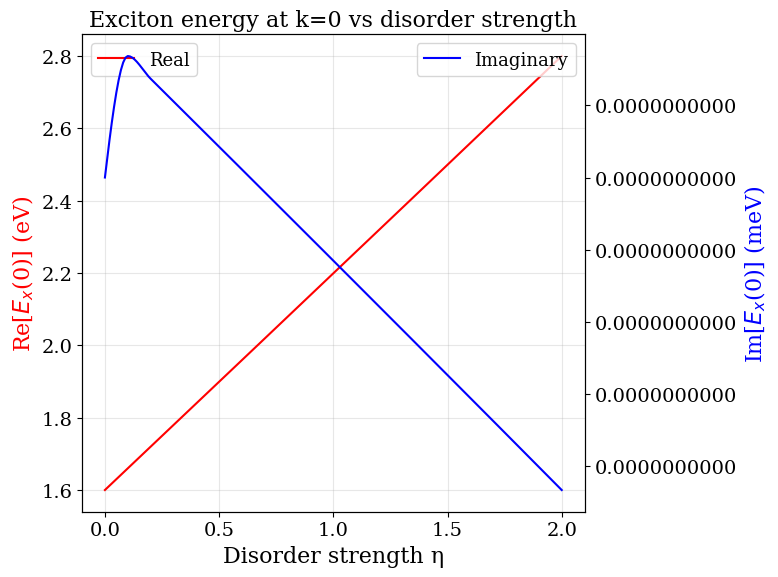

In [4]:
E_ex_k0 = np.array([model.E_ex(np.array([0.0]), eta)[0] for eta in eta_grid])

eta_dense = np.linspace(eta_grid[0], eta_grid[-1], 201)
E_real_dense = PchipInterpolator(eta_grid, np.real(E_ex_k0))(eta_dense)
E_imag_dense = PchipInterpolator(eta_grid, np.imag(E_ex_k0))(eta_dense)

fig, ax = plt.subplots(figsize=(8, 6))
ax_r = ax.twinx()

real_color = CMAP(0.32)
imag_color = CMAP(0.82)
ax.plot(eta_dense, E_real_dense, color=real_color, lw=1.5, label="Real")
ax_r.plot(eta_dense, 1e3 * E_imag_dense, color=imag_color, lw=1.5, label="Imaginary")

ax.set_xlabel("Disorder strength η")
ax.set_ylabel(r"Re[$E_x$(0)] (eV)", color=real_color)
ax_r.set_ylabel(r"Im[$E_x$(0)] (meV)", color=imag_color)
ax.tick_params(axis='y', colors=real_color)
ax_r.tick_params(axis='y', colors=imag_color)
ax.set_title("Exciton energy at k=0 vs disorder strength")
ax.grid(alpha=0.3)
ax.legend(loc="upper left"); ax_r.legend(loc="upper right")
plt.tight_layout()
save_figure(fig, "Eex_k0_vs_eta")
plt.show()


## Dispersion relations

Exciton and photon dispersion for a selected disorder value, and full
exciton / LP dispersions for all η.


Saved  dispersion_disordertuned_cavity.pdf


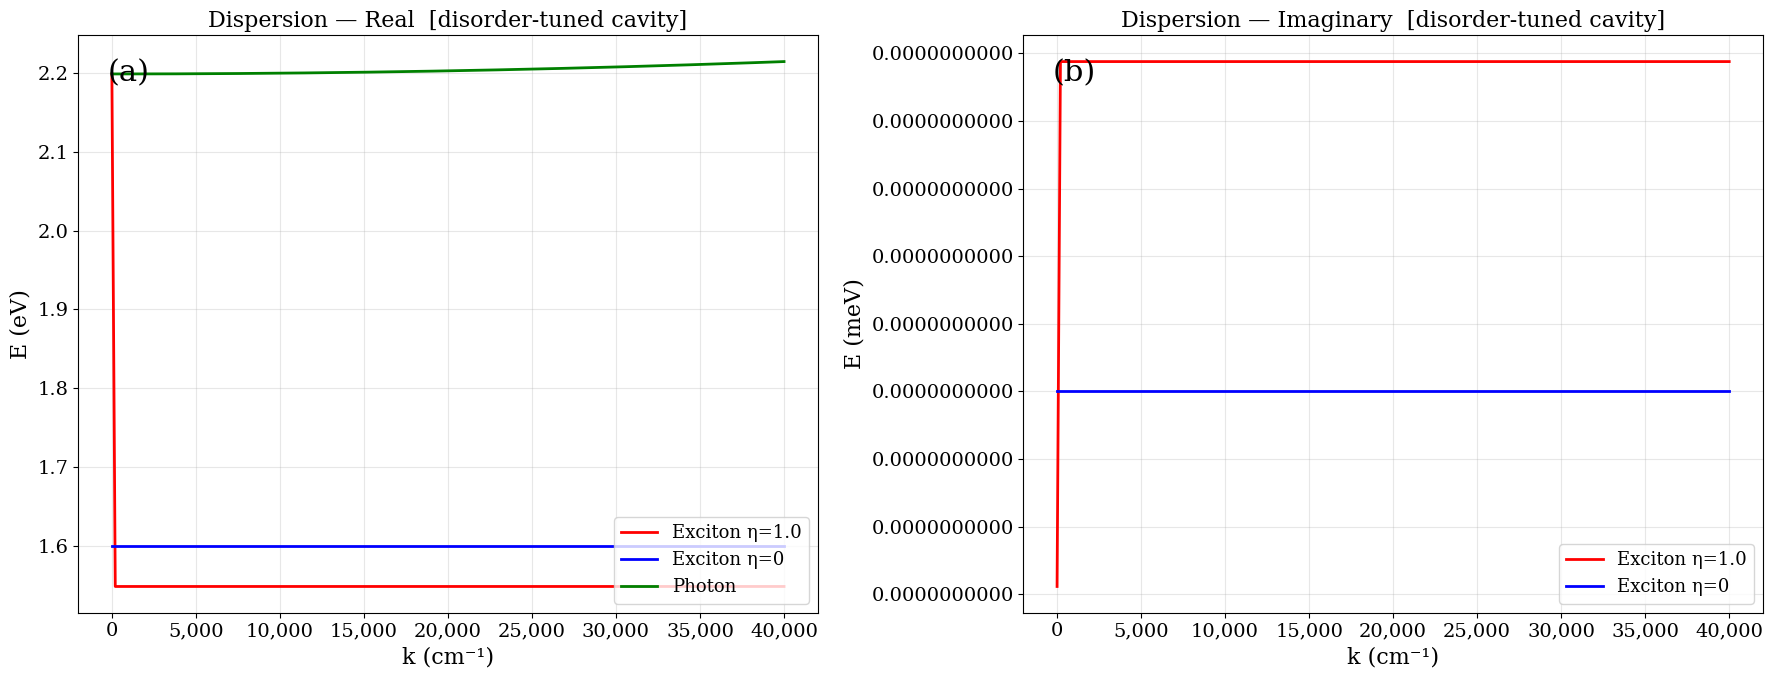

Saved  dispersion_disorderfree_cavity.pdf


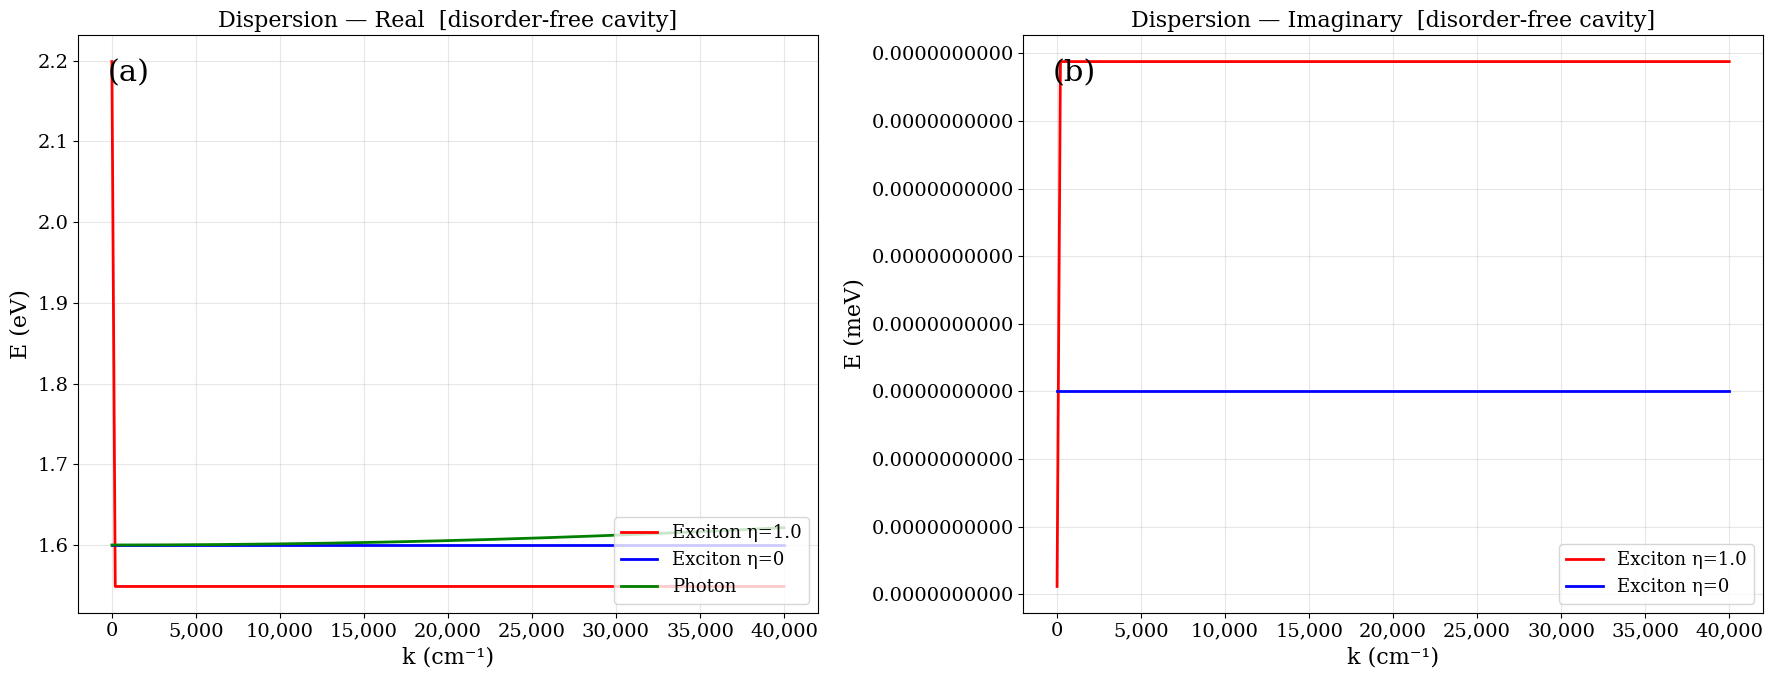

In [5]:
eta_probe = eta_grid[10]
k_cm = k_si_to_cm(k_disp)

E_ex_probe = model.E_ex(k_disp, eta_probe)
E_ex_clean = model.E_ex(k_disp, 0.0)

for tuned in (True, False):
	suffix = cavity_label(tuned)
	E_ph_use = model.E_ph(k_disp, eta_probe) if tuned else model.E_ph_untuned(k_disp)

	fig, axs = plt.subplots(1, 2, figsize=(18, 7))
	axs[0].plot(k_cm, np.real(E_ex_probe), color=CMAP(0.25), lw=2, label=f"Exciton η={eta_probe:.1f}")
	axs[0].plot(k_cm, np.real(E_ex_clean), color=CMAP(0.55), lw=2, label="Exciton η=0")
	axs[0].plot(k_cm, E_ph_use, color=CMAP(0.85), lw=2, label="Photon")
	axs[1].plot(k_cm, 1e3*np.imag(E_ex_probe), color=CMAP(0.25), lw=2, label=f"Exciton η={eta_probe:.1f}")
	axs[1].plot(k_cm, 1e3*np.imag(E_ex_clean), color=CMAP(0.55), lw=2, label="Exciton η=0")

	for ax in axs:
		ax.set_xlabel("k (cm⁻¹)")
		ax.legend(loc="lower right")
		ax.grid(alpha=0.3)
		format_cm_ticks(ax, k_cm.max())
	axs[0].set_ylabel("E (eV)")
	axs[1].set_ylabel("E (meV)")
	axs[0].set_title(f"Dispersion — Real  [{suffix}]")
	axs[1].set_title(f"Dispersion — Imaginary  [{suffix}]")
	axs[0].text(0.04, 0.92, "(a)", transform=axs[0].transAxes, fontsize=22)
	axs[1].text(0.04, 0.92, "(b)", transform=axs[1].transAxes, fontsize=22)

	plt.tight_layout()
	save_figure(fig, f"dispersion_{cavity_slug(tuned)}_cavity", meta={"eta_probe": float(eta_probe), "disorder_tuned": tuned})
	plt.show()


## Lower polariton dispersion — all η


Saved  LP_dispersion_tuned.pdf


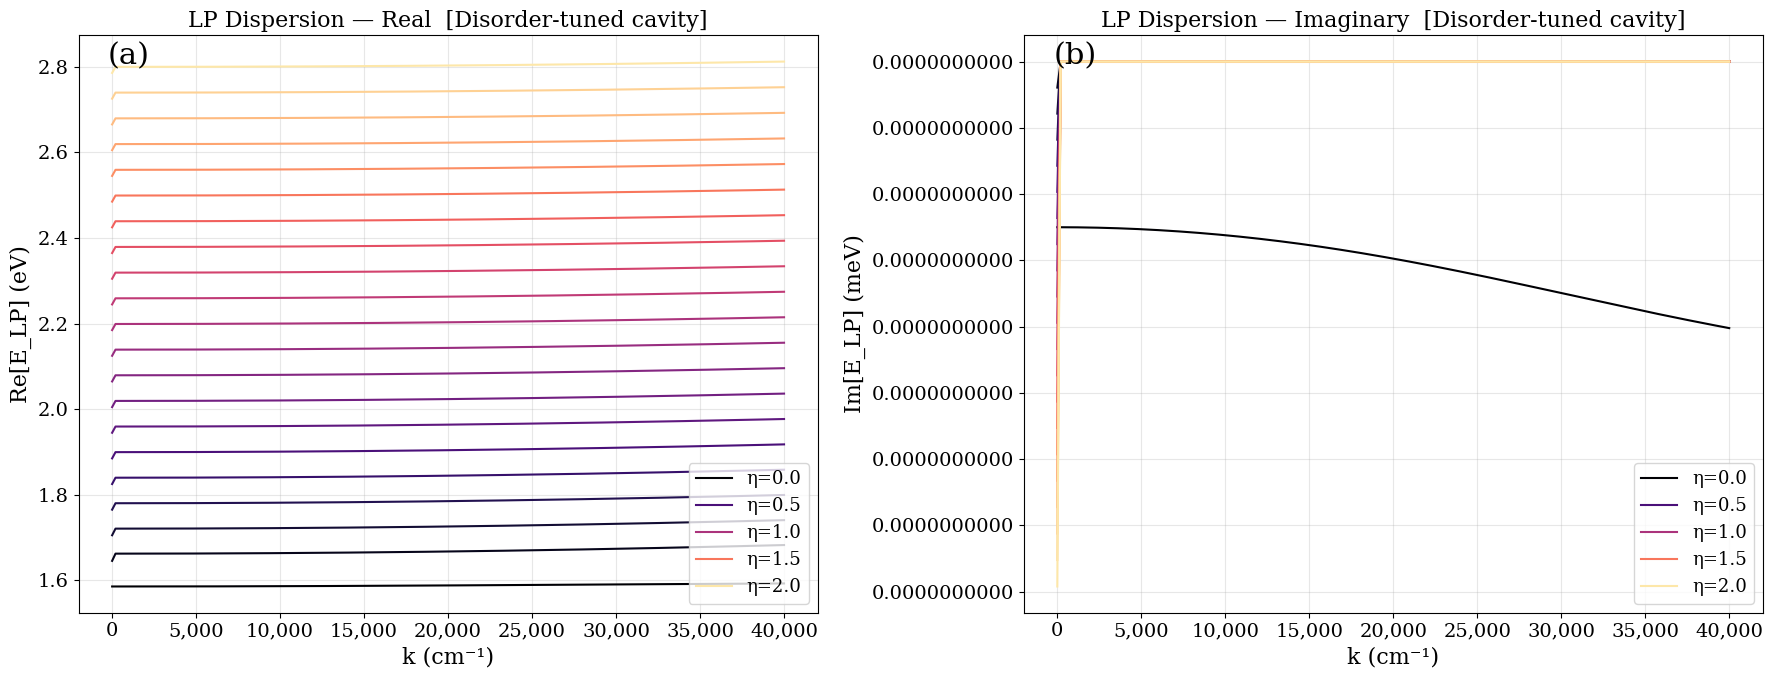

Saved  LP_dispersion_untuned.pdf


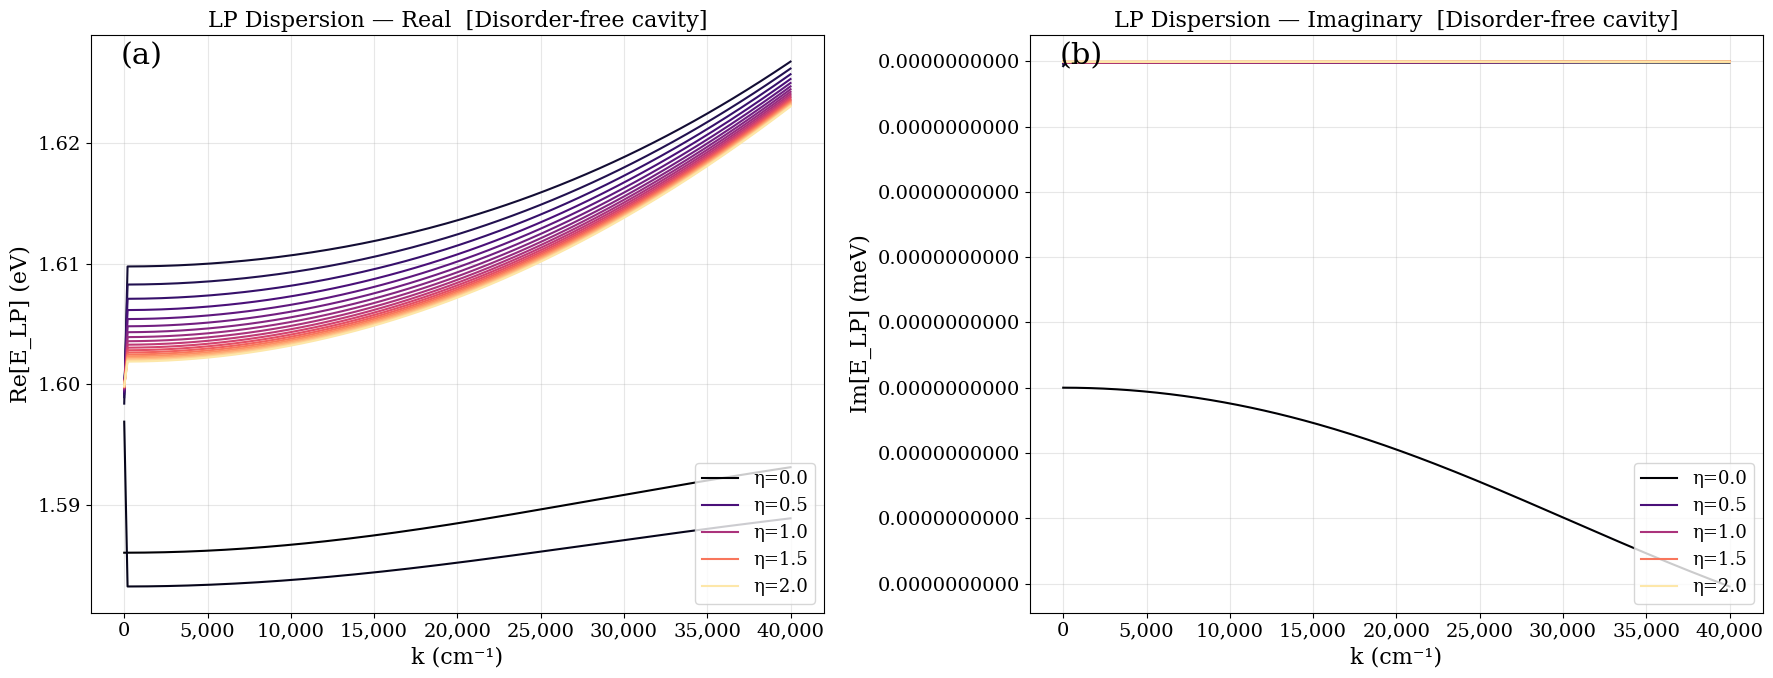

In [6]:
legend_etas = [0.0, 0.5, 1.0, 1.5, 2.0]

for tuned in (True, False):
	label = cavity_label(tuned)
	fig, axs = plt.subplots(1, 2, figsize=(18, 7))
	for ei, eta in enumerate(eta_grid):
		clr = eta_color(ei, len(eta_grid))
		lbl = f"η={eta:.1f}" if eta in legend_etas else "_nolegend_"
		E_lp = model.E_LP(k_disp, eta, disorder_tuned=tuned)
		axs[0].plot(k_si_to_cm(k_disp), np.real(E_lp), color=clr, label=lbl)
		axs[1].plot(k_si_to_cm(k_disp), 1e3 * np.imag(E_lp), color=clr, label=lbl)

	for ax in axs:
		ax.set_xlabel("k (cm⁻¹)")
		ax.legend(loc="lower right")
		ax.grid(alpha=0.3)
		format_cm_ticks(ax, k_si_to_cm(k_disp).max())
	axs[0].set_ylabel("Re[E_LP] (eV)")
	axs[1].set_ylabel("Im[E_LP] (meV)")
	axs[0].set_title(f"LP Dispersion — Real  [{label}]")
	axs[1].set_title(f"LP Dispersion — Imaginary  [{label}]")
	axs[0].text(0.04, 0.95, "(a)", transform=axs[0].transAxes, fontsize=22)
	axs[1].text(0.04, 0.95, "(b)", transform=axs[1].transAxes, fontsize=22)

	plt.tight_layout()
	save_figure(fig, "LP_dispersion_" + cavity_slug(tuned), meta={"disorder_tuned": tuned})
	plt.show()


## Hopfield coefficients


Saved  hopfield_coefficients.pdf


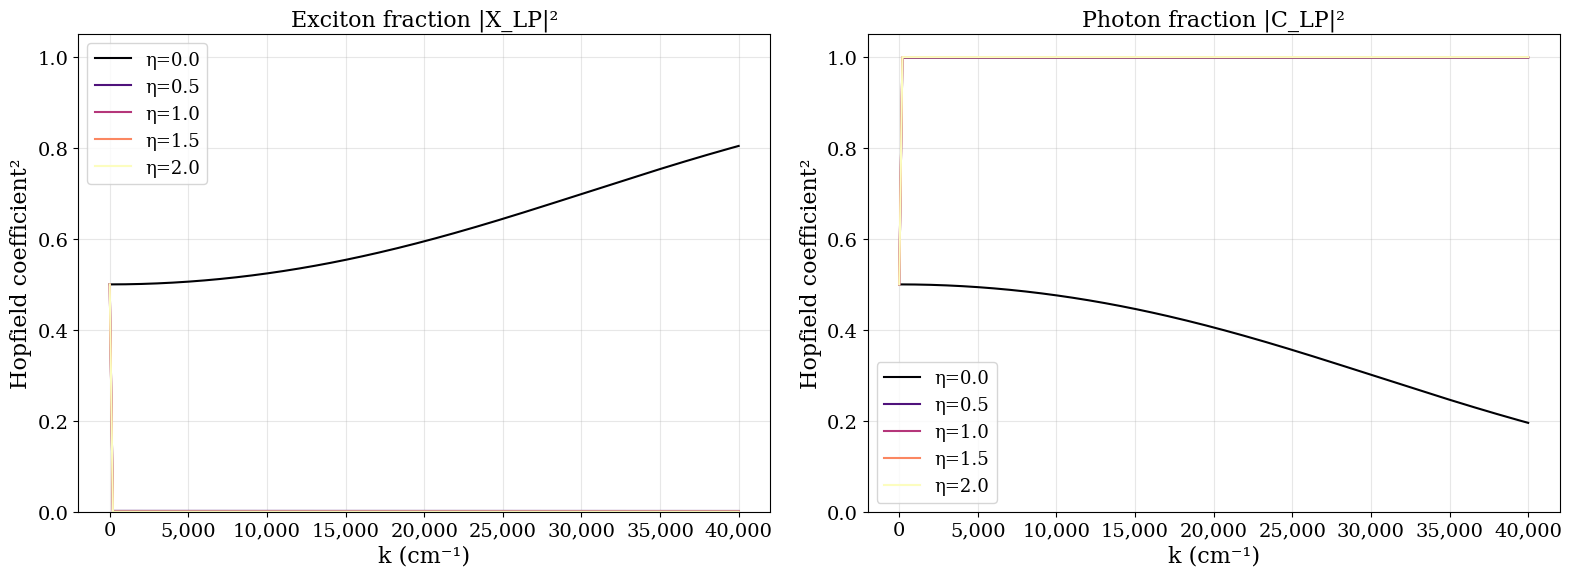

In [7]:
for tuned in (True, False):
	fig, axs = plt.subplots(1, 2, figsize=(16, 6))
	for eta in legend_etas:
		ei = int(np.argmin(np.abs(eta_grid - eta)))
		clr = eta_color(ei, len(eta_grid))
		E_lp = model.E_LP(k_disp, eta, disorder_tuned=tuned)
		X_LP, C_LP = hopfield_coefficients(model, eta, k_disp, E_lp)
		axs[0].plot(k_si_to_cm(k_disp), np.abs(X_LP)**2, color=clr, label=f"η={eta:.1f}")
		axs[1].plot(k_si_to_cm(k_disp), np.abs(C_LP)**2, color=clr, label=f"η={eta:.1f}")

	for ax, title in zip(axs, ["Exciton fraction |X_LP|²", "Photon fraction |C_LP|²"]):
		ax.set_xlabel("k (cm⁻¹)")
		ax.set_ylabel("Hopfield coefficient²")
		ax.set_title(f"{title}  [{cavity_label(tuned)}]")
		ax.set_ylim(0, 1.05)
		ax.legend()
		ax.grid(alpha=0.3)
		format_cm_ticks(ax, k_si_to_cm(k_disp).max())

	plt.tight_layout()
	save_figure(fig, "hopfield_coefficients_" + cavity_slug(tuned), meta={"disorder_tuned": tuned})
	plt.show()


## Detuning Δ(k, η) = E_ph − E_ex


Saved  detuning.pdf


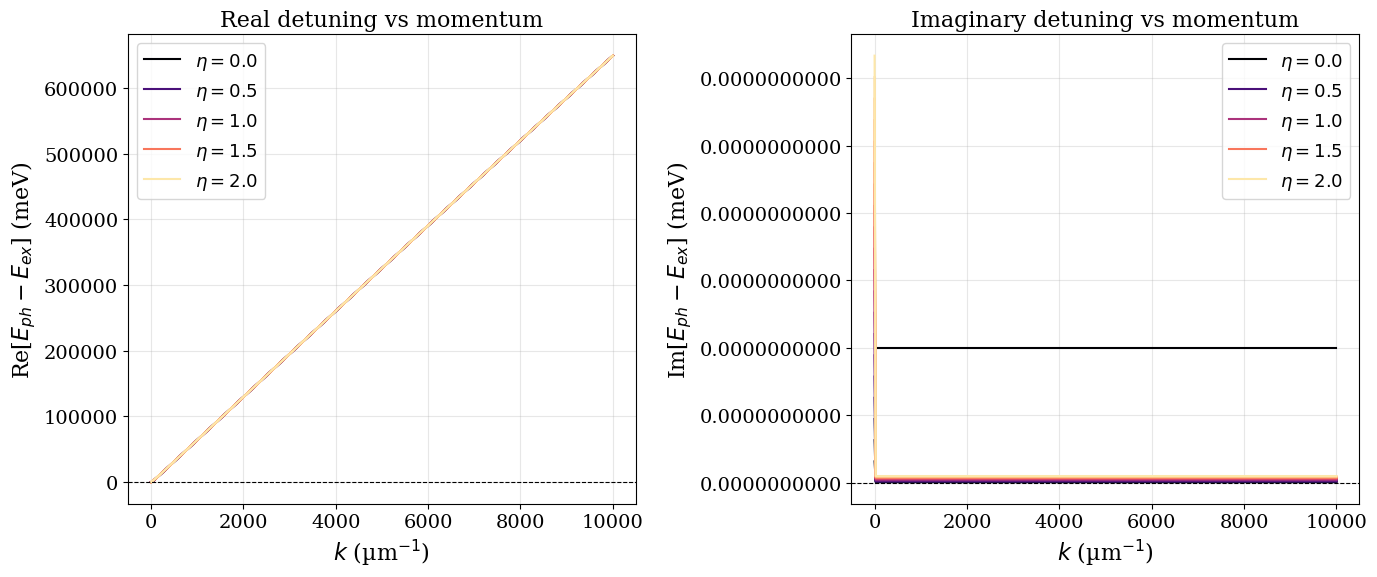

In [8]:
for tuned in (True, False):
	fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
	for ei, eta in enumerate(eta_grid):
		clr = eta_color(ei, len(eta_grid))
		lbl = fr"$\eta={eta:.1f}$" if eta in legend_etas else "_nolegend_"
		E_ph = model.E_ph(k_wide, eta) if tuned else model.E_ph_untuned(k_wide)
		delta = E_ph - model.E_ex(k_wide, eta)
		ax1.plot(k_si_to_cm(k_wide), 1e3 * np.real(delta), color=clr, label=lbl)
		ax2.plot(k_si_to_cm(k_wide), 1e3 * np.imag(delta), color=clr, label=lbl)

	for ax in (ax1, ax2):
		ax.axhline(0, color=CMAP(0.05), lw=0.8, ls='--')
		ax.set_xlabel("k (cm⁻¹)")
		ax.legend()
		ax.grid(alpha=0.3)

	ax1.set_ylabel(r"Re[$E_{ph}-E_{ex}$] (meV)")
	ax1.set_title(f"Real detuning vs momentum  [{cavity_label(tuned)}]")
	ax2.set_ylabel(r"Im[$E_{ph}-E_{ex}$] (meV)")
	ax2.set_title(f"Imaginary detuning vs momentum  [{cavity_label(tuned)}]")

	plt.tight_layout()
	save_figure(fig, "detuning_" + cavity_slug(tuned), meta={"disorder_tuned": tuned})
	plt.show()


## Polariton interaction strength vs k


Saved  g_bare_disorder_tuned.pdf


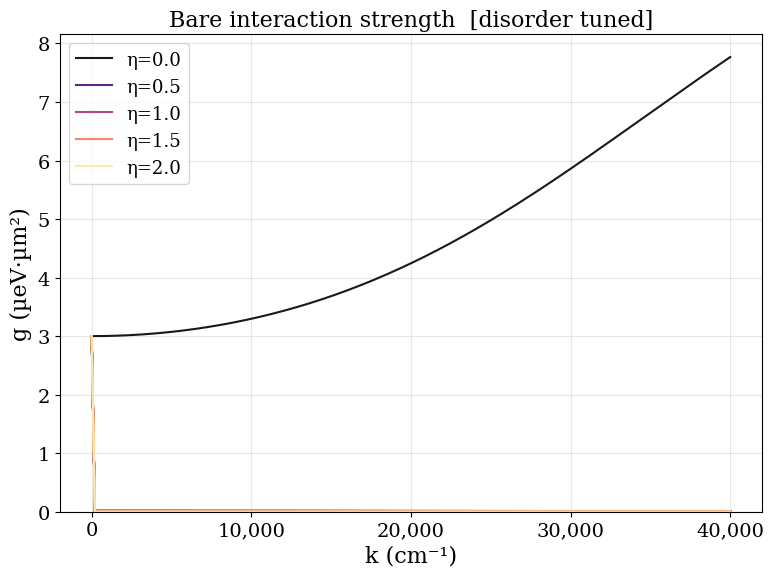

ValueError: Increase L_terms: truncated series cannot reach the target density.

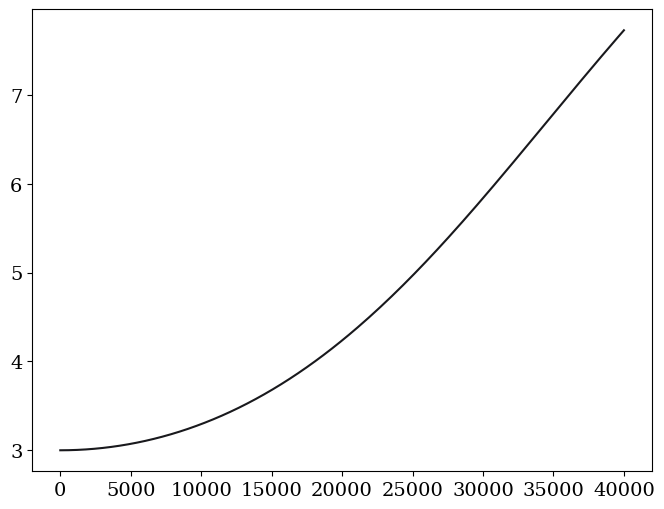

In [9]:
# Parameters for the many-body calculation
L_TERMS = 100
K_UPPER = 1e8    # m^-1
N_K = 100_000

bubble_cache: dict[tuple[float, bool], float] = {}

def bubble_for(eta: float, disorder_tuned: bool) -> float:
	key = (float(eta), bool(disorder_tuned))
	if key not in bubble_cache:
		bubble_cache[key] = Pi0(
			model, eta,
			L_terms=L_TERMS,
			k_upper=K_UPPER,
			n_k=N_K,
			disorder_tuned=disorder_tuned,
		)
	return bubble_cache[key]


def plot_interaction_family(k_values: np.ndarray, *, log_k: bool, name_suffix: str) -> None:
	x_values = k_si_to_cm(k_values)
	for tuned in (True, False):
		for bare, g_label, y_label in [
			(True,  "bare",    "g (µeV·µm²)"),
			(False, "screened", "g' (µeV·µm²)"),
		]:
			fig, ax = plt.subplots(figsize=(8, 6))
			for ei, eta in enumerate(eta_grid):
				clr = eta_color(ei, len(eta_grid))
				lbl = f"η={eta:.1f}" if eta in legend_etas else "_nolegend_"
				bubble = None if bare else bubble_for(eta, tuned)
				g = polariton_interaction_strength(
					model, eta, k_values,
					bare=bare,
					L_terms=L_TERMS,
					k_upper=K_UPPER,
					n_k=N_K,
					disorder_tuned=tuned,
					bubble=bubble,
				)
				ax.plot(x_values, 1e18 * g, color=clr, label=lbl, alpha=0.9)

			ax.set_xlabel("k (cm⁻¹)")
			ax.set_ylabel(y_label)
			ax.set_title(f"{g_label.capitalize()} interaction strength  [{cavity_label(tuned)}]")
			ax.legend()
			ax.set_ylim(0, None)
			ax.grid(alpha=0.3, which="both")
			if log_k:
				ax.set_xscale("log")
				ax.set_xlim(x_values[0], x_values[-1])
			else:
				format_cm_ticks(ax, x_values.max())

			plt.tight_layout()
			save_figure(fig, f"g_{g_label}_{cavity_slug(tuned)}{name_suffix}",
						meta={
							"bare": bare,
							"disorder_tuned": tuned,
							"L_terms": L_TERMS,
							"k_upper": K_UPPER,
							"n_k": N_K,
							"log_k": log_k,
							"k_min_cm_inv": float(x_values[0]),
							"k_max_cm_inv": float(x_values[-1]),
						})
			plt.show()

plot_interaction_family(k_disp, log_k=False, name_suffix="")
plot_interaction_family(k_full_log, log_k=True, name_suffix="_full_logk")
